# Polarization maps

The ``LaserBeam`` objects allow to get useful information about laser polarization and their projection on a given quantization axis. 

Here we illustrate how to use the built-in methods to compute the π, σ+ and σ- components of a laser beam with a given polarization in a complex magnetic field profile.

## Simple example : constant offset magnetic field

We start with a constant offset field along x, and a laser with linear polarization along x. In this case we expect the polarization to the π.

In [9]:
import numpy as np
from atomsmltr.environment import GaussianLaserBeam, MagneticOffset
from atomsmltr.environment import CircularLeft, CircularRight, Linear

# - laser beam propagating along +z, linearly polarized along x
laser = GaussianLaserBeam(direction=(0, 0, 1))
laser.polarization = Linear(angle=0)

# - offset beam along x
mag_field = MagneticOffset((1,0,0))

# - then the laser is π-polarized
B = mag_field.get_value((0,0,0))  # value of the field at origin

# compute the norm of the projection on π, σ+- components
# here we use the 'get_polarization_quant_dict' that returns a dict
print("Norm \n------")
components = laser.get_polarization_quant_dict(B)
for k, v in components.items():
    print(f"{k} > {v:.2f}")

# it is also possible to get the projection (complex)
print("\nAmplitude \n------")
components_amp = laser.get_polarization_quant_amplitude_dict(B)
for k, v in components_amp.items():
    print(f"{k} > {v:.2f}")

Norm 
------
sigma+ > 0.00
sigma- > 0.00
pi > 1.00

Amplitude 
------
sigma+ > 0.00+0.00j
sigma- > -0.00+0.00j
pi > 1.00+0.00j


Now if the laser is polarized along y, we have a σ polarization, i.e. a linear superposition of σ- and σ+ :

In [10]:
# update laser polarization
laser.polarization = Linear(np.pi/2)

# norm
print("Norm \n------")
components = laser.get_polarization_quant_dict(B)
for k, v in components.items():
    print(f"{k} > {v:.2f}")

# amplitude
print("\nAmplitude \n------")
components_amp = laser.get_polarization_quant_amplitude_dict(B)
for k, v in components_amp.items():
    print(f"{k} > {v:.2f}")

Norm 
------
sigma+ > 0.50
sigma- > 0.50
pi > 0.00

Amplitude 
------
sigma+ > 0.00-0.71j
sigma- > -0.00+0.71j
pi > 0.00-0.00j


Finally, let's have the magnetic field aligned with laser propagation, and check that circular polarization correspond to σ+ and σ- polarizations. 

In [13]:
# Update magnetic field
mag_field.field_value = (0,0,1)
B = mag_field.get_value((0,0,0))

# Circular right
laser.polarization = CircularRight()
print("Circular right \n------")
components = laser.get_polarization_quant_dict(B)
for k, v in components.items():
    print(f"{k} > {v:.2f}")

# Circular left
laser.polarization = CircularLeft()
print("\nCircular left \n------")
components = laser.get_polarization_quant_dict(B)
for k, v in components.items():
    print(f"{k} > {v:.2f}")

Circular right 
------
sigma+ > 1.00
sigma- > 0.00
pi > 0.00

Circular left 
------
sigma+ > 0.00
sigma- > 1.00
pi > 0.00


## Complex example : polarization map

Now let's apply this method to compute the polarization projection on a complex magnetic field map.

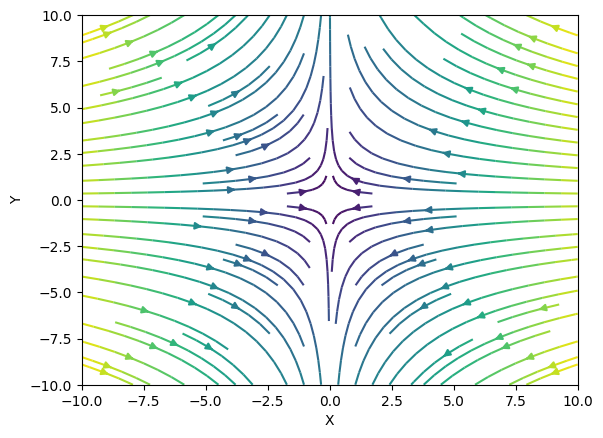

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from atomsmltr.environment import GaussianLaserBeam, MagneticQuadrupoleX
from atomsmltr.environment import CircularLeft

# - define the magnetic field and laser beam
mag_field = MagneticQuadrupoleX(origin=(0,0,0), slope=1)
laser = GaussianLaserBeam(direction=(1,0,0), polarization=CircularLeft())

# - plot the magnetic field
_ = mag_field.plot2D((-10, 10, -10, 10), (100, 100), plane="XY")

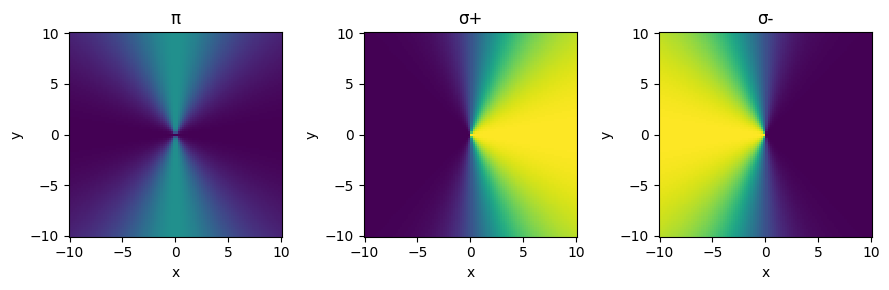

In [37]:
# - compute and plot the polarization map
# prepare grid
position = np.squeeze(np.mgrid[-10:10:100j, -10:10:101j, 0:0:1j]).T

# compute magnetic field value
B = mag_field.get_value(position)

# compute projection
quant = laser.get_polarization_quant(B)
pi, sigma_plus, sigma_minus = quant.T

# plot
X, Y, _ = position.T
fig, axes = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)

axes[0].pcolormesh(X, Y, pi, vmin=0, vmax=1)
axes[0].set_title("π")
axes[1].pcolormesh(X, Y, sigma_plus, vmin=0, vmax=1)
axes[1].set_title("σ+")
axes[2].pcolormesh(X, Y, sigma_minus, vmin=0, vmax=1)
axes[2].set_title("σ-")

for ax in axes:
    ax.set_ylabel("y")
    ax.set_xlabel("x")
plt.show()